# Notes
* I'm not sure I should include a cleaner in the pptx indexing pipeline - could removing empty lines mess up the splitter? After all, \n\n is one of the default separators
* For a given document, if the tagger identifies different tags for different chunks, perhaps we should take all of the tags and use them for all chunks just to make sure we don't miss anything. There's a lot of overlap between disciplines anyway.
* If the tagger returns nothing
    * Should we remove the entry?
    * Should we just take the tags from all other entries and tag the empty entries with those tags?
    * It's not necessarily the shortest chunks that are untagged btw
* The output of the splitter does not include the split overlap information or the source ID - why? Do I have the same issue with PDFs? Or is the issue in fixed vs. recursive chunker?
    * The page numbers are wrong

# Download files

In [1]:
import sys
from dotenv import load_dotenv
import os

load_dotenv(override=True)

if "../app/" not in sys.path:
    sys.path.append("../app/")

print(sys.path)

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/ryanwtsai/repos/lms-ai-agent/app/venv/lib/python3.12/site-packages', '../app/']


In [2]:
import boto3, re

s3_client = boto3.client(
    "s3",
    aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
    aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY"),
    region_name=os.getenv("AWS_REGION"),
)

In [3]:
bucket_name = "content-tagging-lms"

files = [d["Key"] for d in s3_client.list_objects(Bucket=bucket_name)["Contents"] if re.search(".pdf", d["Key"])]

for file in files:
    print(file)
    head, _ = os.path.split(file)
    print(head)
    os.makedirs(head, exist_ok=True)
    s3_client.download_file(bucket_name, file, file)

Content/Excel Fundamental (self-paced)/Excel.pdf
Content/Excel Fundamental (self-paced)
Content/Excel Fundamental (self-paced)/FinTech/Intro to FinTech.pdf
Content/Excel Fundamental (self-paced)/FinTech
Content/Excel Fundamental (self-paced)/Introduction to Excel.pdf
Content/Excel Fundamental (self-paced)


# Use pipeline to chunk

In [5]:
collection_name = "pdf"

In [15]:
from haystack_utilities.pipelines import build_indexing_pipeline

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 100,
    "split_overlap": 20,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 200,
    "split_overlap": 40,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

splitting_options = {
    "split_strategy": "recursive",
    "split_length": 300,
    "split_overlap": 60,
    "split_unit": "word",
    "separators": ["\f", "\n\n", "sentence", "\n", " "]
}

# splitting_options = {
#     "split_strategy": "fixed",
#     "split_by": "word",
#     "split_length": 300,
#     "split_overlap": 60,
#     "split_threshold": 300,
#     "respect_sentence_boundary": False
# }

index_pipe = build_indexing_pipeline(collection_name, splitting_options, file_extension=".pdf", max_content_len_chars=65535, drop_old=True)

In [16]:
fnames = ["Content/Excel Fundamental (self-paced)/Excel.pdf"]

index_results = index_pipe.run({"converter": {"sources": fnames}}, include_outputs_from={"converter", "cleaner", "splitter"})
# results = index_pipe.run({"converter": {"sources": fnames}}, include_outputs_from={"converter", "splitter"})
index_results

No abbreviations file found for en. Using default abbreviations.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

{'writer': {'documents_written': 6},
 'converter': {'documents': [Document(id=4bfa1f54cd3b428a234cef612474289c6965cc6356677f7b855be7978fdf3345, content: '             Excel Fundamentals
                for Business Intelligence & Data Analytics
   
   
   
   
   
   
   
   
   
   
   
   
   ...', meta: {'file_path': 'Excel.pdf'})]},
 'cleaner': {'documents': [Document(id=2db492f46b47d0976f1ed57ca0f4cc83de11f6a449eaad356df21133ec784465, content: 'Excel Fundamentals for Business Intelligence & Data Analytics Copyright © 2021 by WeCloudData Inc. A...', meta: {'file_path': 'Excel.pdf'})]},
 'splitter': {'documents': [Document(id=ad8615e577a17431f4d186fe86b99d521a0b69920f01d337f526ee863f379c20, content: 'Excel Fundamentals for Business Intelligence & Data Analytics Copyright © 2021 by WeCloudData Inc. A...', meta: {'file_path': 'Excel.pdf', 'split_id': 0, 'split_idx_start': 0, '_split_overlap': [], 'page_number': 2}),
   Document(id=985c47890374e6d346459301e1cc64450ad1b12896e59968b8f0ce

In [17]:
if "splitter" in index_results.keys():
    lengths = [len(doc.content) for doc in index_results["splitter"]["documents"]]
    print(f"Max len char = {max(lengths)}")
    print(f"Min len char = {min(lengths)}")

Max len char = 1836
Min len char = 689


(array([1., 0., 0., 0., 0., 0., 1., 0., 0., 4.]),
 array([ 689. ,  803.7,  918.4, 1033.1, 1147.8, 1262.5, 1377.2, 1491.9,
        1606.6, 1721.3, 1836. ]),
 <BarContainer object of 10 artists>)

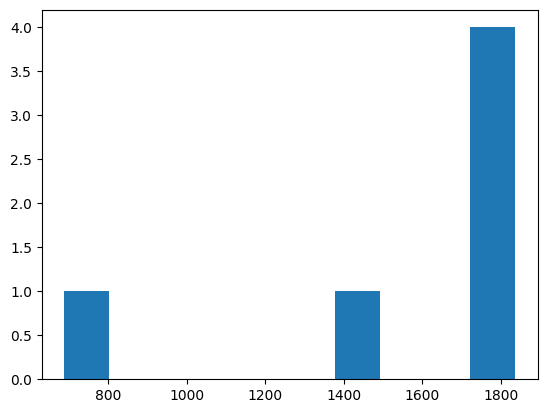

In [18]:
import matplotlib.pyplot as plt

plt.hist(lengths)

In [10]:
if not os.path.exists("./experiments"):
    os.mkdir("./experiments")

component_names = ["converter", "cleaner"]

for name in component_names:
    if name in index_results.keys():
        fname = f"./experiments/{name}_output.txt"
        with open(fname, "w") as file:
            file.write(index_results[name]["documents"][0].content)
            print(f"{fname} written.")


component_names = ["splitter"]

for name in component_names:
    if name in index_results.keys():
        fname = f"./experiments/{name}_output.txt"

        if os.path.exists(fname):
            os.remove(fname)

        with open(f"./experiments/{name}_output.txt", "a") as file:
            for doc in index_results[name]["documents"]:
                file.write(f"{doc.content}\n{"-"*200}\n")
            print(f"{fname} written.")

./experiments/converter_output.txt written.
./experiments/cleaner_output.txt written.
./experiments/splitter_output.txt written.


# Use pipeline to tag

In [19]:
from haystack_utilities.pipelines import build_tagging_pipeline

prompt_template_tagging = """
    I am doing a content tagging project. The goal of the project is to tag teaching materials.

    Tags: [Machine Learning Engineering, Data Analysis, Data Engineering, Data Science, Other].

    Here are some examples of topics for each tag:
    * Machine Learning Engineering: AI, Generative AI, Large Language Model, Computer Vision, MLOps
    * Data Science: Data Science
    * Data Analysis: Data Analytics, Analytics, Excel, Business Intelligence, SQL
    * Data Engineering: Data Engineer, Big Data Engineer, Cloud Engineer, DevOps Engineer, Spark
    * Other: Web Scraping

    I will give you a text chunk, delimited in triple backticks, and you will identify the most likely tag based on the text chunk.

    Please format the tag as a string inside a 1-element Python list, e.g. ["Machine Learning Engineer"].
    
    Respond only with the list, no other text.

    If none of the tags apply, respond with an empty list, [].

    Text chunk: ```{{doc.content}}```
    """

tag_pipe = build_tagging_pipeline(collection_name, prompt_template_tagging)

In [20]:
tag_results = tag_pipe.run({})

tag_results

{'upserter': {'documents_written': 6}}

# Check tagging results

In [21]:
from pymilvus import MilvusClient
import os
from dotenv import load_dotenv

load_dotenv(override=True)

client = MilvusClient(
    uri=os.getenv("ZILLIZ_CLUSTER_ENDPOINT"),
    token=os.getenv("ZILLIZ_CLUSTER_TOKEN")
)

In [23]:
tags = ["Machine Learning Engineering", "Data Analysis", "Data Engineering", "Data Science", "Other"]

for tdx, tag in enumerate(tags):
    filter = f"json_contains(metadata['tags'], '{tag}')"
    res = client.query(
        collection_name=collection_name,
        filter=filter,
        output_fields=["text", "metadata"],
    )
    
    print(f"{tag}: {len(res)}")

    if os.path.exists(f"./experiments/tagged_chunks_{tdx}.txt"):
        os.remove(f"./experiments/tagged_chunks_{tdx}.txt")
    
    with open(f"./experiments/tagged_chunks_{tdx}.txt", "a") as file:
        for r in res:
            file.write(f"{r['text']}\n{"-"*50}\n")

Machine Learning Engineering: 0
Data Analysis: 6
Data Engineering: 0
Data Science: 0
Other: 0


In [25]:
filter='metadata["tags"] == []'
res = client.query(
    collection_name="pdf",
    filter=filter,
    output_fields=["text", "metadata"],
)

print(len(res))

if os.path.exists("./experiments/untagged_chunks.txt"):
    os.remove("./experiments/untagged_chunks.txt")

with open("./experiments/untagged_chunks.txt", "a") as file:
    for r in res:
        file.write(f"{r['text']}\n{"-"*50}\n")

0


In [26]:
lengths = [len(r['text']) for r in res]
print(lengths)

[]


# Sanity-check retrieval and generation

In [36]:
from haystack_utilities.pipelines import build_rag_pipeline

prompt_rag = """
You will be provided some context, followed by the page number that this context comes from.
Answer the question based on the contexts, and reference the page numbers from which your answer is generated.

Context:
{% for doc in documents %}
   {{ doc.content }} 
   Page: {{ doc.meta['metadata']["page_number"]}}
   -----
{% endfor %}
-----
Question: {{ query }}
-----
Answer:
"""

# prompt_rag = """
# Please answer the question. Ignore the context provided.

# Context:
# {% for doc in documents %}
#    {{ doc.content }} 
#    Page: {{ doc.meta['metadata']["page_number"]}}
#    -----
# {% endfor %}
# -----
# Question: {{ query }}
# -----
# Answer:
# """

rag_pipe = build_rag_pipeline(collection_name, prompt_rag, top_k=6)

In [37]:
query = "Please provide a list of Excel functions I should learn."

In [38]:
rag_results = rag_pipe.run({"query_embedder": {"text": query}, "prompt_builder": {"query": query}}, include_outputs_from={"retriever", "prompt_builder"})

rag_results

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

{'generator': {'replies': ['You should learn the following Excel functions, which are commonly used by data analysts:\n\n**Calculations:**\n- SUM\n- AVERAGE\n- MIN\n- MAX\n- MEDIAN\n- COUNT\n- COUNTA\n- SUMIFS\n- AVERAGEIFS\n- ROUND\n\n**Text Functions:**\n- TRIM\n- PROPER\n- UPPER\n- LOWER\n- CONCATENATE\n- LEFT\n- RIGHT\n- MID\n- LEN\n\n**Logical Functions:**\n- IF\n- IFS\n- AND\n- OR\n- IFERROR\n\n**Lookup Functions:**\n- VLOOKUP\n- HLOOKUP\n- INDEX MATCH\n- XLOOKUP\n\nThese functions will provide a solid foundation for performing various analyses and tasks in Excel (Page 3).'],
  'meta': [{'model': 'gpt-4o-mini-2024-07-18',
    'index': 0,
    'finish_reason': 'stop',
    'usage': {'completion_tokens': 163,
     'prompt_tokens': 2006,
     'total_tokens': 2169,
     'completion_tokens_details': CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0),
     'prompt_tokens_details': PromptTokensDetails(audio_tokens=0, cac

In [39]:
if "prompt_builder" in rag_results:
    print(rag_results["prompt_builder"]["prompt"])


You will be provided some context, followed by the page number that this context comes from.
Answer the question based on the contexts, and reference the page numbers from which your answer is generated.

Context:

   Interface Basics Familiarizing yourself with the overall interface of the tool and where to find things • Splash Screen (Start Screen) • Quick Access Toolbar + Customization • Ribbon (since 2007) • Name Box • Formula Bar • Status Bar • Workbook • Worksheets (used to be limited to 255 sheets, now it’s unlimited – only restricted by the memory on your computer) • Cells (1,048,576 rows by 16,384 columns = 17,179,869,184 cells per worksheet) Excel Fundamentals for Business Intelligence & Data Analytics | Copyright © 2021 by WeCloudData Inc. All rights reserved. This Course Notes or any portion thereof may not be reproduced or usedin any manner whatsoever without the express written permission of WeCloudData Inc. Excel’s Data Types The 3 types of data that can be contained in

In [40]:
if not os.path.exists("./experiments"):
    os.mkdir("./experiments")
        
fname = f"./experiments/generator_output.txt"
with open(fname, "w") as file:
    file.write(rag_results["generator"]["replies"][0])
    print(f"{fname} written.")


component_names = ["retriever"]

for name in component_names:
    if name in rag_results.keys():
        fname = f"./experiments/{name}_output.txt"

        if os.path.exists(fname):
            os.remove(fname)

        with open(f"./experiments/{name}_output.txt", "a") as file:
            for doc in rag_results[name]["documents"]:
                file.write(f"{doc.content}\n{"-"*200}\n")
            print(f"{fname} written.")

./experiments/generator_output.txt written.
./experiments/retriever_output.txt written.


# Drop collection

In [81]:
client.list_collections()
# client.drop_collection("media_transcripts")

['HaystackCollection', 'TaggingTestCollection', 'pptx']